# 2. Machine Learning for Regression

In [1]:
import pandas as pd
import numpy as np

## 2.2 Data Preparation

In [2]:
df = pd.read_csv('../data/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [5]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [6]:
df.dtypes == 'str'

make                  True
model                 True
year                 False
engine_fuel_type      True
engine_hp            False
engine_cylinders     False
transmission_type     True
driven_wheels         True
number_of_doors      False
market_category       True
vehicle_size          True
vehicle_style         True
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [7]:
df.dtypes[df.dtypes == 'str']

make                 str
model                str
engine_fuel_type     str
transmission_type    str
driven_wheels        str
market_category      str
vehicle_size         str
vehicle_style        str
dtype: object

In [8]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [9]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df[strings]

,make,model,engine_fuel_type,transmission_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,bmw,1_series_m,premium_unleaded_(required),manual,rear_wheel_drive,"factory_tuner,luxury,high-performance",compact,coupe
1,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,convertible
2,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,high-performance",compact,coupe
3,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,"luxury,performance",compact,coupe
4,bmw,1_series,premium_unleaded_(required),manual,rear_wheel_drive,luxury,compact,convertible
...,...,...,...,...,...,...,...,...
11909,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11910,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11911,acura,zdx,premium_unleaded_(required),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback
11912,acura,zdx,premium_unleaded_(recommended),automatic,all_wheel_drive,"crossover,hatchback,luxury",midsize,4dr_hatchback


In [11]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

## 2.3 Exploratory data analysis

In [12]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [13]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print()

make
0    bmw
1    bmw
2    bmw
3    bmw
4    bmw
Name: make, dtype: str

model
0    1_series_m
1      1_series
2      1_series
3      1_series
4      1_series
Name: model, dtype: str

year
0    2011
1    2011
2    2011
3    2011
4    2011
Name: year, dtype: int64

engine_fuel_type
0    premium_unleaded_(required)
1    premium_unleaded_(required)
2    premium_unleaded_(required)
3    premium_unleaded_(required)
4    premium_unleaded_(required)
Name: engine_fuel_type, dtype: str

engine_hp
0    335.0
1    300.0
2    300.0
3    230.0
4    230.0
Name: engine_hp, dtype: float64

engine_cylinders
0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: engine_cylinders, dtype: float64

transmission_type
0    manual
1    manual
2    manual
3    manual
4    manual
Name: transmission_type, dtype: str

driven_wheels
0    rear_wheel_drive
1    rear_wheel_drive
2    rear_wheel_drive
3    rear_wheel_drive
4    rear_wheel_drive
Name: driven_wheels, dtype: str

number_of_doors
0    2.0
1    2.0
2    2.0
3

In [14]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

### Distribution of price

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

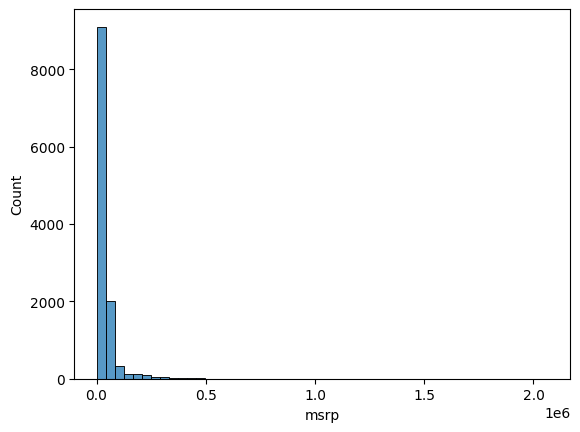

In [16]:
sns.histplot(df.msrp, bins=50);

We can see long tail distribution in the graph above.
1e6 - one million, 1_000_000.
Possible prices might be around 2 million.

Zoom in a bit to see prices up to 100_000

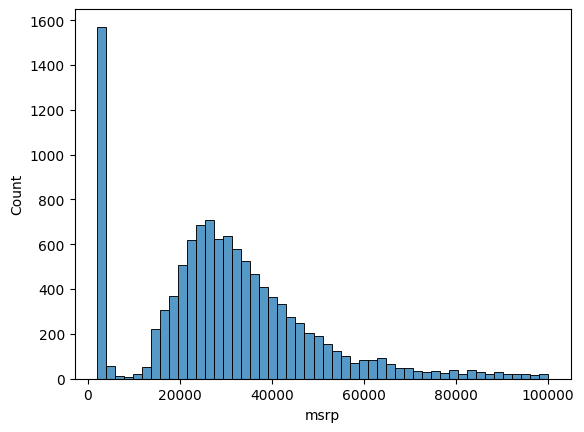

In [17]:
sns.histplot(df.msrp[df.msrp < 100_000], bins=50);

We can see a bunch of cars at minimal price, around 1000, the average in this zoomed in is around 25_000.
This kind of distribution is not very good for ML. The tail from the zoomed-out graph will easily confuse ML models.
We want to get rid of that tail.  
To remove it we apply a logarithms to obtain a logarithnmic distribution to get more compact values.  
What's the reason for that? Simple mathematical behavior of logarithms - log of large values are not increasing rapidly.

In [18]:
np.log([1, 10, 1000, 100_000])

array([ 0.        ,  2.30258509,  6.90775528, 11.51292546])

The problem with common logs is that if we calculate logs for zero values, we will get a warning because the log(0) is undefined.
The solution is add to 1 to all values and then apply a log on them.

In [19]:
np.log([0 + 1, 1 + 1, 10 + 1, 1000 + 1, 100_000 + 1])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

But we don't want to do this manually each time.   
There is a method in numpy that applies such a log on our data.

In [20]:
np.log1p([0, 1, 10, 1000, 100_000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [21]:
price_logs = np.log1p(df.msrp)

In [22]:
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

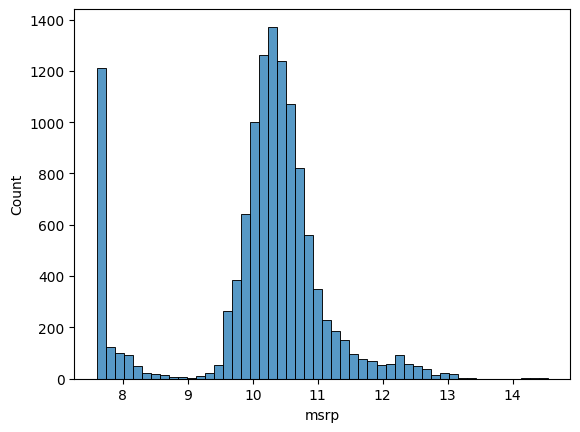

In [23]:
sns.histplot(price_logs, bins=50);

The tail is gone and all large prices have collapsed to the area around 14.
All the prices for usual consumers are pivoting around 10 and 11.
This shape is now called a **normal distribution**.  
Models work best with normal distributions of the target variable.

## Missing values

In [24]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Setting up the validation framework

In [25]:
len(df)

11914

In [26]:
len(df) * .2

2382.8

In [27]:
n = len(df)
n_val = int(n * .2)
n_test = int(n * .2)
n_train = int(n * .6)

In [28]:
n, n_val + n_test + n_train

(11914, 11912)

We can see that we left out 2 records, so we need different approach.

In [29]:
n_train = n - n_val - n_test
n_train

7150

In [30]:
n, n_val + n_test + n_train

(11914, 11914)

In [31]:
n_val, n_test, n_train

(2382, 2382, 7150)

In [32]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [33]:
df.iloc[11910:]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,28995


In [34]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7146,mazda,navajo,1994,regular_unleaded,160.0,6.0,manual,four_wheel_drive,2.0,NaN,compact,2dr_suv,18,14,586,2000
7147,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65055
7148,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,67220


In [35]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7150,lincoln,navigator,2015,regular_unleaded,365.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,63645
7151,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,22,16,61,63195
7152,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76650
7153,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,69135
7154,lincoln,navigator,2016,regular_unleaded,380.0,6.0,automatic,rear_wheel_drive,4.0,luxury,large,4dr_suv,20,15,61,65560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37380
9528,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,extended_cab_pickup,23,16,1385,40100
9529,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42560
9530,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,42860


In [36]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
9532,chevrolet,silverado_1500,2015,regular_unleaded,355.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,23,16,1385,47575
9533,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,31940
9534,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,24,18,1385,38335
9535,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,4.0,flex_fuel,large,extended_cab_pickup,24,18,1385,35870
9536,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,rear_wheel_drive,2.0,flex_fuel,large,regular_cab_pickup,24,18,1385,28155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


Another problem is that all the data is sequential - we have to shuffle the data.

In [37]:
idx = np.arange(n)

In [38]:
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [39]:
np.random.shuffle(idx)

In [40]:
idx

array([7069, 9992, 5510, ..., 8705, 7482, 4388], shape=(11914,))

In [41]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [42]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7069,ford,mustang_svt_cobra,1999,regular_unleaded,320.0,8.0,manual,rear_wheel_drive,2.0,"factory_tuner,performance",compact,convertible,22,15,5657,5193
9992,nissan,stanza,1992,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,26,19,2009,2000
5510,pontiac,grand_prix,2008,regular_unleaded,303.0,8.0,automatic,front_wheel_drive,4.0,"factory_tuner,high-performance",large,sedan,25,16,210,29325
10127,suzuki,sx4,2011,regular_unleaded,150.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,33,23,481,15195
2385,porsche,cayman,2014,premium_unleaded_(required),275.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,30,20,1715,52600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5987,lexus,is_350,2015,premium_unleaded_(required),306.0,6.0,automatic,all_wheel_drive,4.0,"luxury,performance",midsize,sedan,26,19,454,42300
7164,lincoln,navigator,2017,regular_unleaded,380.0,6.0,automatic,four_wheel_drive,4.0,luxury,large,4dr_suv,19,15,61,76645
2618,chevrolet,c/k_1500_series,1997,regular_unleaded,200.0,6.0,manual,rear_wheel_drive,2.0,NaN,large,extended_cab_pickup,20,15,1385,2517
9498,chevrolet,silverado_1500,2015,flex-fuel_(unleaded/e85),285.0,6.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,22,17,1385,37680


The problem with this approach that each time we will get different random portions.  
We need to keep it reproducible with pseudo-random shuffling. 

In [43]:
np.random.seed(2)
np.random.shuffle(idx)

Split the data again.

In [44]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [45]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
10681,ford,transit_connect,2017,flex-fuel_(unleaded/e85),169.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,cargo_minivan,27,20,5657,25425
3580,land_rover,discovery_series_ii,2002,premium_unleaded_(required),188.0,8.0,automatic,four_wheel_drive,4.0,luxury,midsize,4dr_suv,16,12,258,37150
2875,bentley,continental_gt,2016,premium_unleaded_(required),582.0,12.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,21,12,520,214600
2435,toyota,celica,2004,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,33,25,2031,18370
8212,dodge,ram_van,2000,regular_unleaded,225.0,8.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,17,12,1851,2320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11573,volvo,xc60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,31,24,870,36400
7499,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,19,15,2202,27300
11087,chevrolet,uplander,2008,regular_unleaded,240.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,compact,passenger_minivan,23,16,1385,21540
10728,ford,transit_wagon,2017,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,3.0,diesel,large,passenger_van,19,14,5657,40770


In [46]:
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
7626,honda,pilot,2017,regular_unleaded,280.0,6.0,automatic,all_wheel_drive,4.0,crossover,midsize,4dr_suv,26,19,2202,47070
1540,cadillac,ats,2015,premium_unleaded_(recommended),272.0,4.0,automatic,rear_wheel_drive,4.0,"luxury,performance",compact,sedan,30,21,1624,42660
7373,mitsubishi,outlander_sport,2017,regular_unleaded,148.0,4.0,automatic,four_wheel_drive,4.0,crossover,compact,4dr_suv,29,23,436,22495
10208,toyota,tacoma,2016,regular_unleaded,278.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,24,19,2031,28845
7326,kia,optima,2015,regular_unleaded,192.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,34,23,1720,24340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11074,chevrolet,uplander,2006,regular_unleaded,201.0,6.0,automatic,front_wheel_drive,4.0,NaN,compact,passenger_minivan,23,16,1385,19250
2822,plymouth,colt,1992,regular_unleaded,92.0,4.0,manual,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,32,25,535,2000
8176,dodge,ram_pickup_1500,2009,regular_unleaded,390.0,8.0,automatic,rear_wheel_drive,4.0,NaN,large,crew_cab_pickup,20,14,1851,40270
7621,honda,pilot,2016,regular_unleaded,280.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,27,19,2202,37655


In [47]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6879,lincoln,mkx,2016,regular_unleaded,303.0,6.0,automatic,all_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,26,17,61,44045
1212,honda,accord,2015,regular_unleaded,278.0,6.0,manual,front_wheel_drive,2.0,performance,midsize,coupe,28,18,2202,30775
4354,ford,explorer_sport_trac,2008,regular_unleaded,210.0,6.0,automatic,rear_wheel_drive,4.0,NaN,compact,crew_cab_pickup,20,14,5657,27490
3977,hyundai,entourage,2008,regular_unleaded,250.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,passenger_minivan,23,16,1439,23995
4733,ford,five_hundred,2006,regular_unleaded,203.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,sedan,23,17,5657,28230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,bmw,6_series,2017,premium_unleaded_(required),445.0,8.0,automatic,rear_wheel_drive,2.0,"luxury,high-performance",midsize,coupe,24,17,3916,89000
1367,cadillac,allante,1991,regular_unleaded,200.0,8.0,automatic,front_wheel_drive,2.0,"luxury,performance",compact,convertible,20,14,1624,2000
11253,chevrolet,venture,2003,regular_unleaded,185.0,6.0,automatic,front_wheel_drive,4.0,NaN,compact,passenger_minivan,24,17,1385,22465
5956,oldsmobile,intrigue,2002,regular_unleaded,215.0,6.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,27,18,26,28070


In [48]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

We are not interested in the original indices, so we will reset all of them.

In [49]:
df_train = df_train.reset_index(drop=True)

In [50]:
df_val = df_val.reset_index(drop=True)

In [51]:
df_test = df_test.reset_index(drop=True)

Next, we need to do some transformation of the target variable.

In [52]:
df_train.msrp

0        25425
1        37150
2       214600
3        18370
4         2320
         ...  
7145     36400
7146     27300
7147     21540
7148     40770
7149     93200
Name: msrp, Length: 7150, dtype: int64

In [53]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

Remove the target variable from the training, validation and test subsets

In [54]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [55]:
len(y_train)

7150

In [56]:
y_train

array([10.14352755, 10.52274597, 12.27653577, ...,  9.97771337,
       10.61572632, 11.44251373], shape=(7150,))

# Linear regression

In [57]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,ford,transit_connect,2017,flex-fuel_(unleaded/e85),169.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,cargo_minivan,27,20,5657
1,land_rover,discovery_series_ii,2002,premium_unleaded_(required),188.0,8.0,automatic,four_wheel_drive,4.0,luxury,midsize,4dr_suv,16,12,258
2,bentley,continental_gt,2016,premium_unleaded_(required),582.0,12.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,21,12,520
3,toyota,celica,2004,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,33,25,2031
4,dodge,ram_van,2000,regular_unleaded,225.0,8.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,17,12,1851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,volvo,xc60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,31,24,870
7146,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,19,15,2202
7147,chevrolet,uplander,2008,regular_unleaded,240.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,compact,passenger_minivan,23,16,1385
7148,ford,transit_wagon,2017,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,3.0,diesel,large,passenger_van,19,14,5657


In [58]:
df_train.iloc[10]

make                           subaru
model                    xv_crosstrek
year                             2014
engine_fuel_type     regular_unleaded
engine_hp                       160.0
engine_cylinders                  4.0
transmission_type           automatic
driven_wheels         all_wheel_drive
number_of_doors                   4.0
market_category      crossover,hybrid
vehicle_size                  compact
vehicle_style                 4dr_suv
highway_mpg                        33
city_mpg                           29
popularity                        640
Name: 10, dtype: object

In [59]:
xi = [311, 20, 454]

We will select engine_hp, city_mpg and popularity features for analysis on this one particular example.  
$x_{i} = [311, 20, 454]$  
$i = 10$  
$g(x_{i}) ≈ y_{i}$

In [60]:
def g(xi):
    # do something
    return 10_000

In [61]:
g(xi)

10000

Formula for linear regression:    
$g(x_{i}) = w_{0} + w_{1}*x_{i1} + w_{2}*x_{i2} + w_{3}*x_{i3}$

Final formula:  
$g(x_{i}) = w_{0} + \sum_{j=1}^{3}w_{j}x_{ij}$

where $w_{0}$ is a bias term.  
In our case, since index starts from 0 and goes to n-1, our formula is written like this:  
$g(x_{i}) = w_{0} + \sum_{j=0}^{n-1}w_{j}x_{ij}$

In [62]:
w0 = 0
w = [1, 1, 1]

In [63]:
def linear_regression(xi):
    n = len(xi)

    pred = w0
    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [64]:
linear_regression(xi)

785

Let's use some concrete values

In [65]:
w0 = 7.17
w = [0.01, 0.04, 0.002]

In [66]:
linear_regression(xi)

11.988

Bias term $w_0$ is a prediction about a specific car if we don't know anything about it.  
But we actually know something about that car - we know the engine_hp. For each unit of engine_hp the price increases by 0.01.  
The more engine_hp the car has, the more expensive it becomes.  
For the city_mpg the more the car consumes in the city, the more expensive it becomes. For each extra mpg the price increases by 0.04.  
Logic behind the statement: the more the car consumes it must be one of the more expensive ones.  
The last feature is popularity (social media mentions) which has a low weight and is not affecting the price so much.  
For every extra mention the price increases by factor 0.002.  

The value yielded from the linear_regression in this case (11.988) does not represent the final price of the car, this is the log(y + 1) price.   
We need to undo the logarithm to obtain the final value.

In [67]:
np.exp(linear_regression(xi)) - 1

np.float64(160812.40553386137)

In [68]:
np.expm1(linear_regression(xi))

np.float64(160812.40553386137)

So, for this particular car the price prediction is around $160812.41.

# 2.6 Linear regression vector form

$g(x_{i}) = w_{0} + \sum_{j=1}^{3}w_{j}x_{ij}$  
$g(\mathbf{x}_i)=w_0 * x_{i0}+\mathbf{x}_i^T\mathbf{w}$  

where the imaginary feature $x_{i0}$ is always one.

$\mathbf{w} = [w_{0}, w_{1}, w_{2}, ..., w_{n}]$ is a n + 1 dimensional vector.  
$\mathbf{x_{i}} = [1, x_{i1}, x_{i2}, ..., x_{in}]$   

Then we do the dot product between them.

Vector by vector product

In [69]:
def dot(xi, w):
    n = len(xi)

    res = 0

    for j in range(n):
        res = res + xi[j] * w[j]

    return res

In [70]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [71]:
w_new = [w0] + w

In [72]:
w_new

[7.17, 0.01, 0.04, 0.002]

In [73]:
[1] + [1, 2, 3]

[1, 1, 2, 3]

In [74]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [75]:
linear_regression(xi)

11.988

Now, we will thing about all the examples, not just concrete one.
We have a marix $\mathbf{X}$ of size m x (n+1) which means m rows and (n+1) columns.
We also have a vector $\mathbf{w}$.  
For each of these rows, we multiply the row with the vector.
The results or the predictions $\mathbf{y_p}$ are on the right-hand side of the equal sign.

$
\begin{bmatrix}
1 & x_{11} & \cdots & x_{1n}\\
1 & x_{21} & \cdots & x_{2n}\\
1 & \vdots & \ddots & \vdots\\
1 & x_{m1} & \cdots & x_{mn}
\end{bmatrix}
\begin{bmatrix}
w_0\\
w_1\\
\vdots\\
w_n
\end{bmatrix}
=
\begin{bmatrix}
x_1^T w\\
x_2^T w\\
\vdots\\
x_m^T w
\end{bmatrix}
$

In [76]:
xi = [311, 20, 454]
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [77]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 311, 20,  454]

X = [x1, x2, x10]
X

[[1, 148, 24, 1385], [1, 132, 25, 2031], [1, 311, 20, 454]]

In [78]:
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  311,   20,  454]])

In [79]:
X.dot(w_new)

array([12.38 , 13.552, 11.988])

In [80]:
X @ w_new

array([12.38 , 13.552, 11.988])

For each car now we have a prediction of its price.

In [81]:
def linear_regression(X):
    return X.dot(w_new)

In [82]:
linear_regression(X)

array([12.38 , 13.552, 11.988])

# 2.7 Training a linear regression model

We tend to be as close as possible to the following situation:  
$\mathbf{Xw} = \mathbf{y}$  
but in reality, we never get there, so the formula looks more like the following:  
$\mathbf{Xw} ≈ \mathbf{y}$  
We want to find the weights, so we need to multiply the $\mathbf{Xw}$ by $\mathbf{X^{-1}}$ (inverted matrix), 
and the other side to get the following expression:  
$\mathbf{X^{-1}} \mathbf{Xw} = \mathbf{X^{-1}} \mathbf{y}$  
so the expression becomes:  
$\mathbf{I} \mathbf{w} = \mathbf{X^{-1}} \mathbf{y}$  
if identity matrix exists, or more precisely: 
$\mathbf{w} = \mathbf{X^{-1}} \mathbf{y}$.

But the problem is that $\mathbf{X}$ is not rectangular matrix, and the inverse does not exist. 
That means that for our system of equations solution does not exist.  
So the goal is to find an approximate solution like this:  

$\mathbf{X^{T}} \mathbf{Xw} = \mathbf{X^{T}} \mathbf{y}$  

The matrix $\mathbf{X^{T}} \mathbf{X}$ is called **Gram matrix** and for it the inverse exists because it's squared  
with dimension (n+1) * (n+1). It doesn't always, and we will talk about it later.  

So, to calculate the weights, we have to multiply the gram matrix by its inverse to get the following expression:  
$(\mathbf{X^{T}X})^{-1} \mathbf{X^{T}Xw} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$  
and again, we get the following:  
$\mathbf{I} \mathbf{w} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$ or:  
$\mathbf{w} = (\mathbf{X^{T}X})^{-1}\mathbf{X^{T}} \mathbf{y}$  

$\mathbf{w}$ is not the solution of the system (the solution does not exist) but represents the closest possible solution.  
This can be proved mathematically (a very useful book for learning more of the mathematics regarding that - Elements of Statistical Learning).

In [83]:
def train_linear_regression(X, y):
    pass

In [84]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11,   86],
    [158, 24,  185],
    [172, 25,  201],
    [413, 11,   86],
    [ 38, 54,  185],
    [142, 25,  431],
    [453, 31,   86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

Include the bias term (the baseline)

In [85]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [86]:
list(np.column_stack([ones, X]))

[array([1.000e+00, 1.480e+02, 2.400e+01, 1.385e+03]),
 array([1.000e+00, 1.320e+02, 2.500e+01, 2.031e+03]),
 array([  1., 453.,  11.,  86.]),
 array([  1., 158.,  24., 185.]),
 array([  1., 172.,  25., 201.]),
 array([  1., 413.,  11.,  86.]),
 array([  1.,  38.,  54., 185.]),
 array([  1., 142.,  25., 431.]),
 array([  1., 453.,  31.,  86.])]

In [87]:
X = np.column_stack([ones, X])

In [88]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [89]:
# Gram matrix
XTX = X.T.dot(X)
XTX

array([[9.000000e+00, 2.109000e+03, 2.300000e+02, 4.676000e+03],
       [2.109000e+03, 6.964710e+05, 4.411500e+04, 7.185400e+05],
       [2.300000e+02, 4.411500e+04, 7.146000e+03, 1.188030e+05],
       [4.676000e+03, 7.185400e+05, 1.188030e+05, 6.359986e+06]])

In [90]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.30686958e+00, -5.39612291e-03, -6.21325581e-02,
        -6.61016816e-04],
       [-5.39612291e-03,  1.11633857e-05,  8.66973393e-05,
         1.08664195e-06],
       [-6.21325581e-02,  8.66973393e-05,  1.46189255e-03,
         8.57849603e-06],
       [-6.61016816e-04,  1.08664195e-06,  8.57849603e-06,
         3.60215866e-07]])

In [91]:
# check
XTX.dot(XTX_inv).round(1)

array([[ 1., -0.,  0.,  0.],
       [-0.,  1.,  0., -0.],
       [-0.,  0.,  1.,  0.],
       [-0., -0.,  0.,  1.]])

We have an indentity matrix. The values are not exactly 0 above and below the diagonal, but close enough.

In [92]:
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([ 2.58447541e+04, -1.60890647e+01, -1.99472549e+02, -1.22802883e+00])

In [93]:
w0 = w_full[0]
w = w_full[1:]

In [94]:
w0, w

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

Negative values mean that price goes down if the feature value goes up. For example, greater car age, lower the price.

In [95]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

This time we don't need to put ones as the first column in $\mathbf{X}$, the algorithm does this for us.

In [96]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11,   86],
    [158, 24,  185],
    [172, 25,  201],
    [413, 11,   86],
    [ 38, 54,  185],
    [142, 25,  431],
    [453, 31,   86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [97]:
train_linear_regression(X, y)

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

# 2.8 Car price baseline model

In [98]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,ford,transit_connect,2017,flex-fuel_(unleaded/e85),169.0,4.0,automatic,front_wheel_drive,4.0,NaN,compact,cargo_minivan,27,20,5657
1,land_rover,discovery_series_ii,2002,premium_unleaded_(required),188.0,8.0,automatic,four_wheel_drive,4.0,luxury,midsize,4dr_suv,16,12,258
2,bentley,continental_gt,2016,premium_unleaded_(required),582.0,12.0,automatic,all_wheel_drive,2.0,"exotic,luxury,high-performance",midsize,coupe,21,12,520
3,toyota,celica,2004,regular_unleaded,140.0,4.0,automatic,front_wheel_drive,2.0,hatchback,compact,2dr_hatchback,33,25,2031
4,dodge,ram_van,2000,regular_unleaded,225.0,8.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,17,12,1851
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,volvo,xc60,2015,regular_unleaded,240.0,4.0,automatic,front_wheel_drive,4.0,"crossover,luxury",midsize,4dr_suv,31,24,870
7146,honda,passport,2001,regular_unleaded,205.0,6.0,automatic,four_wheel_drive,4.0,NaN,midsize,4dr_suv,19,15,2202
7147,chevrolet,uplander,2008,regular_unleaded,240.0,6.0,automatic,front_wheel_drive,4.0,flex_fuel,compact,passenger_minivan,23,16,1385
7148,ford,transit_wagon,2017,regular_unleaded,275.0,6.0,automatic,rear_wheel_drive,3.0,diesel,large,passenger_van,19,14,5657


The next goal is to extract numerical columns from the train set.

In [99]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [100]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [101]:
base = ['engine_hp','engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']
df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,169.0,4.0,27,20,5657
1,188.0,8.0,16,12,258
2,582.0,12.0,21,12,520
3,140.0,4.0,33,25,2031
4,225.0,8.0,17,12,1851
...,...,...,...,...,...
7145,240.0,4.0,31,24,870
7146,205.0,6.0,19,15,2202
7147,240.0,6.0,23,16,1385
7148,275.0,6.0,19,14,5657


Extract the values from the basic numeric columns.

In [105]:
X_train = df_train[base].values
X_train

array([[1.690e+02, 4.000e+00, 2.700e+01, 2.000e+01, 5.657e+03],
       [1.880e+02, 8.000e+00, 1.600e+01, 1.200e+01, 2.580e+02],
       [5.820e+02, 1.200e+01, 2.100e+01, 1.200e+01, 5.200e+02],
       ...,
       [2.400e+02, 6.000e+00, 2.300e+01, 1.600e+01, 1.385e+03],
       [2.750e+02, 6.000e+00, 1.900e+01, 1.400e+01, 5.657e+03],
       [4.200e+02, 6.000e+00, 2.700e+01, 1.700e+01, 1.715e+03]],
      shape=(7150, 5))

In [106]:
y_train

array([10.14352755, 10.52274597, 12.27653577, ...,  9.97771337,
       10.61572632, 11.44251373], shape=(7150,))

Train the model

In [107]:
train_linear_regression(X_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

We have some missing values we need to fix.

In [108]:
df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    24
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

The easiest approach is to fill them with zeroes.

In [109]:
df_train[base].fillna(0).isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

That way we kind of make the model ignore those rows.  
$g(x_{i}) = w_{0} + x_{i1}*w_{1} + x_{i2}*w_{2}$  

Say $x_{i1}$ is missing, the term becomes  
$g(x_{i}) = w_{0} + x_{i2}*w_{2}$  

Zeros are not always the best approach to deal with missing values.  
For example, it does not make much sense for engine horsepower to be 0 hp.  
It's like there is an engine with 0 cylinders.  
Since we don't want to complicate the procedure, we will take this approach for now.

In [110]:
X_train = df_train[base].fillna(0).values
X_train

array([[1.690e+02, 4.000e+00, 2.700e+01, 2.000e+01, 5.657e+03],
       [1.880e+02, 8.000e+00, 1.600e+01, 1.200e+01, 2.580e+02],
       [5.820e+02, 1.200e+01, 2.100e+01, 1.200e+01, 5.200e+02],
       ...,
       [2.400e+02, 6.000e+00, 2.300e+01, 1.600e+01, 1.385e+03],
       [2.750e+02, 6.000e+00, 1.900e+01, 1.400e+01, 5.657e+03],
       [4.200e+02, 6.000e+00, 2.700e+01, 1.700e+01, 1.715e+03]],
      shape=(7150, 5))

In [112]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.959080970166693),
 array([ 9.26142807e-03, -1.40799610e-01,  1.67326043e-02,  1.16351248e-02,
        -1.78759134e-05]))

The next step is to take those weights and make predictions.

In [114]:
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.54442264,  8.97656375, 12.1413475 , ...,  9.8832798 ,
       10.04086322, 11.62300335], shape=(7150,))

Next, we will plot the prodictions to see if they look similar to the original target variable data that we want to predict.

<Axes: ylabel='Count'>

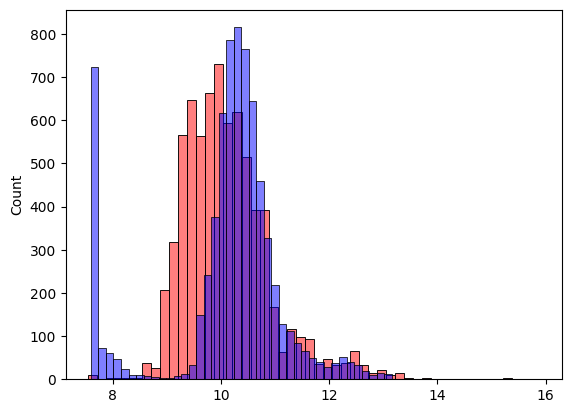

In [116]:
sns.histplot(y_pred, color='red', alpha=.5, bins=50)
sns.histplot(y_train, color='blue', alpha=.5, bins=50)

Our model predicts smaller value and we can see the peak of the distribution for the y_pred slightly moved to the left.
Just by looking the histogram we can see that our model is not 